<a href="https://colab.research.google.com/github/SuyashDubey02/starbucks-customer-order-analysis/blob/main/Copy_of_starbucks_customer_ordering_patterns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
uploaded=files.upload()

Saving starbucks_customer_ordering_patterns.csv to starbucks_customer_ordering_patterns.csv


## **(A). Basic Data Understanding**

In [5]:
import pandas as pd
df = pd.read_csv('starbucks_customer_ordering_patterns.csv')
df.head()

,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
0,CUST_12974,ORD_00000001,2024-03-25,08:47,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,Male,False,5,0,14.48,8.2,Refresher,False,False,4
1,CUST_08235,ORD_00000002,2025-07-18,08:02,Fri,Mobile App,STR_425,Urban,Northeast,35-44,Female,True,1,3,9.52,5.4,Brewed Coffee,False,True,4
2,CUST_00393,ORD_00000003,2025-01-15,05:40,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,Female,False,2,1,9.32,4.9,Brewed Coffee,False,False,5
3,CUST_06936,ORD_00000004,2024-07-30,15:10,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,Female,True,2,1,9.55,3.5,Refresher,False,False,4
4,CUST_09800,ORD_00000005,2024-06-18,07:38,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,Female,False,3,1,12.24,4.1,Frappuccino,False,False,3


In [ ]:
df.shape

(100000, 20)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   customer_id            100000 non-null  object 
 1   order_id               100000 non-null  object 
 2   order_date             100000 non-null  object 
 3   order_time             100000 non-null  object 
 4   day_of_week            100000 non-null  object 
 5   order_channel          100000 non-null  object 
 6   store_id               100000 non-null  object 
 7   store_location_type    100000 non-null  object 
 8   region                 100000 non-null  object 
 9   customer_age_group     100000 non-null  object 
 10  customer_gender        100000 non-null  object 
 11  is_rewards_member      100000 non-null  bool   
 12  cart_size              100000 non-null  int64  
 13  num_customizations     100000 non-null  int64  
 14  total_spend            100000 non-nul

In [ ]:
df.describe()

,cart_size,num_customizations,total_spend,fulfillment_time_min,customer_satisfaction
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,3.741510,1.81077,14.866771,4.546080,3.687530
std,1.697817,1.46280,5.506800,1.550269,1.184123
min,1.000000,0.00000,3.510000,1.000000,1.000000
25%,3.000000,1.00000,10.837500,3.400000,3.000000
50%,4.000000,2.00000,14.170000,4.400000,4.000000
75%,5.000000,3.00000,18.180000,5.500000,5.000000
max,10.000000,8.00000,40.310000,11.200000,5.000000


In [ ]:
df.isnull().sum()

,0
customer_id,0
order_id,0
order_date,0
order_time,0
day_of_week,0
order_channel,0
store_id,0
store_location_type,0
region,0
customer_age_group,0


In [ ]:
df.duplicated().sum()

np.int64(0)

## **(B). Convert Date + Time**

In [6]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_hour'] = pd.to_datetime(df['order_time'], format='mixed').dt.hour
df['month'] = df['order_date'].dt.month

In [7]:
df['order_date']

,order_date
0,2024-03-25
1,2025-07-18
2,2025-01-15
3,2024-07-30
4,2024-06-18
...,...
99995,2025-09-17
99996,2024-08-03
99997,2025-01-11
99998,2025-10-23


In [ ]:
df['order_hour']

,order_hour
0,8
1,8
2,5
3,15
4,7
...,...
99995,17
99996,8
99997,16
99998,18


In [ ]:
df['month']

,month
0,3
1,7
2,1
3,7
4,6
...,...
99995,9
99996,8
99997,1
99998,10


## **(C). Revenue KPIs**

In [8]:
total_revenue = df['total_spend'].sum()
avg_order_value = df['total_spend'].mean()
avg_fulfillment = df['fulfillment_time_min'].mean()

In [9]:
total_revenue

np.float64(1486677.0799999998)

In [10]:
avg_order_value

np.float64(14.866770799999998)

In [11]:
avg_fulfillment

np.float64(4.546079999999999)

## **(D). Top Selling Categories**

In [12]:
df.groupby('drink_category')['total_spend'].sum().sort_values(ascending=False)

,total_spend
drink_category,
Refresher,249661.53
Tea,249342.47
Frappuccino,248127.59
Espresso,247606.75
Other,246010.35
Brewed Coffee,245928.39


## **(E). Order Channel Analysis**

In [13]:
df.groupby('order_channel').agg({
    'total_spend':'sum',
    'order_id':'count',
    'customer_satisfaction':'mean'
})

,total_spend,order_id,customer_satisfaction
order_channel,,,
Drive-Thru,349392.50,27996,3.443456
In-Store Cashier,276008.48,22063,3.700177
Kiosk,92665.25,7420,3.597978
Mobile App,768610.85,42521,3.857294


## **(F). Reward Member Analysis**

In [14]:
df.groupby('is_rewards_member').agg({
    'total_spend':'mean',
    'cart_size':'mean',
    'customer_satisfaction':'mean'
})

,total_spend,cart_size,customer_satisfaction
is_rewards_member,,,
False,14.089233,3.627393,3.64981
True,15.718710,3.866547,3.72886


## **(G). Time-Based Peak Hours**

<Axes: xlabel='order_hour'>

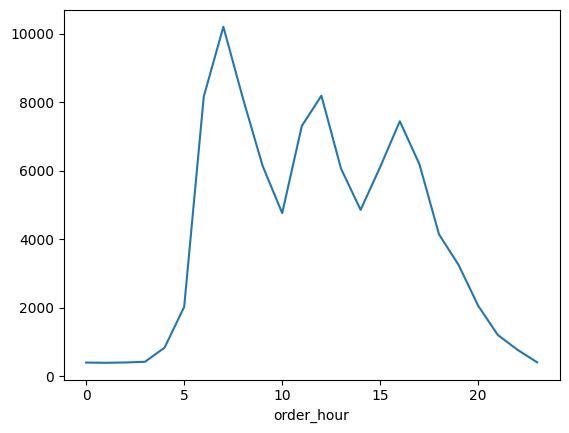

In [15]:
df.groupby('order_hour')['order_id'].count().plot(kind='line')

## **(H). Region Performance**

In [16]:
df.groupby('region').agg({
    'total_spend':'sum',
    'order_id':'count',
    'customer_satisfaction':'mean'
}).sort_values('total_spend', ascending=False)

,total_spend,order_id,customer_satisfaction
region,,,
West,337395.29,22608,3.686173
Southeast,300627.88,20223,3.703209
Southwest,292800.21,19663,3.702436
Midwest,288626.52,19470,3.669594
Northeast,267227.18,18036,3.674762


## **(I). Customer Satisfaction Drivers**

In [17]:
df[['total_spend','cart_size','fulfillment_time_min',
    'num_customizations','customer_satisfaction']].corr()

,total_spend,cart_size,fulfillment_time_min,num_customizations,customer_satisfaction
total_spend,1.000000,0.900137,-0.012112,0.409149,0.065598
cart_size,0.900137,1.000000,-0.007605,0.095733,0.032730
fulfillment_time_min,-0.012112,-0.007605,1.000000,-0.010998,-0.047873
num_customizations,0.409149,0.095733,-0.010998,1.000000,0.049720
customer_satisfaction,0.065598,0.032730,-0.047873,0.049720,1.000000


## **(J). Customization Impact**

In [18]:
df.groupby('num_customizations')['customer_satisfaction'].mean()

,customer_satisfaction
num_customizations,
0,3.614453
1,3.650176
2,3.694478
3,3.750960
4,3.781647
5,3.797487
6,3.826328
7,3.917960
8,3.746835


# **Best Python Visualizations**


In [22]:
import matplotlib.pyplot as plt

## **1. Revenue by Region**

<Axes: xlabel='region'>

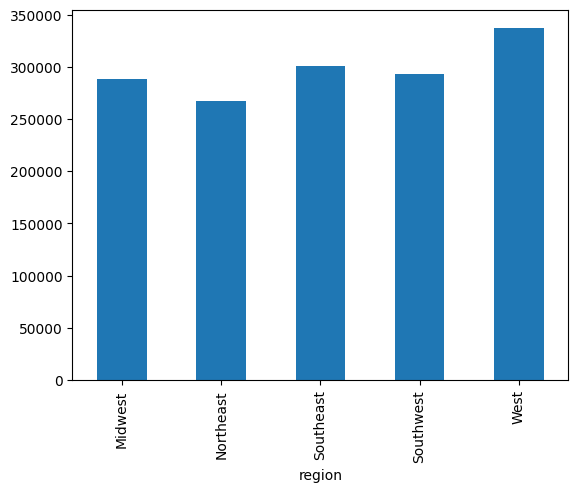

In [19]:
df.groupby("region")['total_spend'].sum().plot(kind='bar')

## **2. Peak Hour Trend**

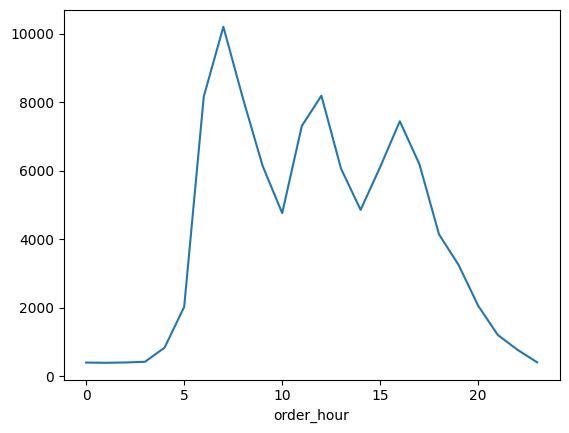

In [23]:
df.groupby('order_hour')['order_id'].count().plot(kind='line')
plt.show()

## **3. Satisfaction vs Fulfillment**

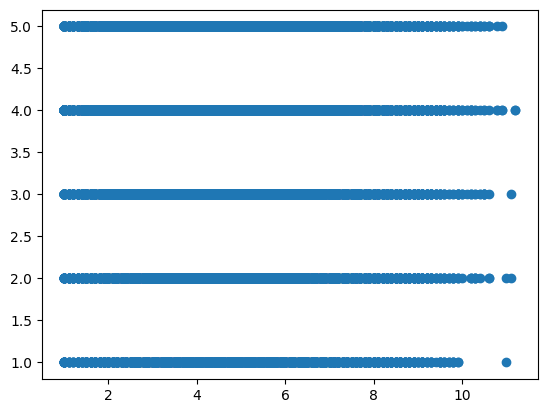

In [26]:
plt.scatter(df['fulfillment_time_min'], df['customer_satisfaction'])
plt.show()